In [3]:
import requests
import pandas as pd

base = "https://api.db.nomics.world/v22/series/CSO/RIQ02"
rows, offset = [], 0

while True:
    r = requests.get(base, params={
        "q": "Dublin", "observations": 1,
        "limit": 1000, "offset": offset, "format": "json"
    }, timeout=180)
    r.raise_for_status()
    data = r.json()["series"]
    docs = data["docs"]
    for d in docs:
        for p, v in zip(d["period"], d["value"]):
            rows.append({"series_name": d["series_name"],
                         "series_code": d["series_code"],
                         "period": p, "value": v})
    offset += len(docs)
    print("Loaded series:", offset, "of", data["num_found"])
    if not docs or offset >= data["num_found"]:
        break

df = pd.DataFrame(rows)

# Split the long name into clean columns
parts = df["series_name"].str.split(" – ", expand=True)
df["bedrooms"] = parts[1]
df["property_type"] = parts[2]
df["location"] = parts[3]
df["value"] = pd.to_numeric(df["value"], errors="coerce")

print(df.shape)
print(df["location"].unique())
print(df["bedrooms"].unique())
print(df["property_type"].unique())
print(df["period"].min(), "to", df["period"].max())
df.head()

Loaded series: 1000 of 7014
Loaded series: 2000 of 7014
Loaded series: 3000 of 7014
Loaded series: 4000 of 7014
Loaded series: 5000 of 7014
Loaded series: 6000 of 7014
Loaded series: 7000 of 7014
Loaded series: 7014 of 7014
(512022, 7)
['Dublin' 'Balbriggan, Dublin' 'Blackrock, Dublin' 'Booterstown, Dublin'
 'Cabinteely, Dublin' 'Citywest, Dublin' 'Dalkey, Dublin'
 'Donabate, Dublin' 'Dun Laoghaire, Dublin' 'Glenageary, Dublin'
 'Howth, Dublin' 'Killiney, Dublin' 'Kinsealy, Dublin' 'Lucan, Dublin'
 'Lusk, Dublin' 'Malahide, Dublin' 'Monkstown, Dublin'
 'Mount Merrion, Dublin' 'Portmarnock, Dublin' 'Rathcoole, Dublin'
 'Rush, Dublin' 'Saggart, Dublin' 'Sandycove, Dublin' 'Shankill, Dublin'
 'Skerries, Dublin' 'Stepaside, Dublin' 'Stillorgan, Dublin'
 'Swords, Dublin' 'Dublin 1' 'I.F.S.C., Dublin 1'
 'Parnell Street, Dublin 1' 'Spencer Dock, Dublin 1'
 'Summerhill, Dublin 1' 'Dublin 2' 'Aungier Street, Dublin 2'
 'Charlemont Street, Dublin 2' 'Grand Canal Dock, Dublin 2'
 'Grand Canal Sq

,series_name,series_code,period,value,bedrooms,property_type,location
0,RTB Average Monthly Rent Report – All bedrooms...,RIQ02.-.-.120500,2007-Q4,1312.69,All bedrooms,All property types,Dublin
1,RTB Average Monthly Rent Report – All bedrooms...,RIQ02.-.-.120500,2008-Q1,1330.34,All bedrooms,All property types,Dublin
2,RTB Average Monthly Rent Report – All bedrooms...,RIQ02.-.-.120500,2008-Q2,1324.99,All bedrooms,All property types,Dublin
3,RTB Average Monthly Rent Report – All bedrooms...,RIQ02.-.-.120500,2008-Q3,1286.49,All bedrooms,All property types,Dublin
4,RTB Average Monthly Rent Report – All bedrooms...,RIQ02.-.-.120500,2008-Q4,1255.69,All bedrooms,All property types,Dublin


In [4]:
df["date"] = pd.PeriodIndex(df["period"], freq="Q").to_timestamp()
df = df.dropna(subset=["value"])
df["location"] = df["location"].str.strip()

# Only the main Dublin postal districts (Dublin 1, Dublin 2 ... Dublin 6W ... Dublin 24)
districts = df[df["location"].str.match(r"^Dublin \d{1,2}W?$")]
dublin = df[(df["location"] == "Dublin") &
            (df["bedrooms"] == "All bedrooms") &
            (df["property_type"] == "All property types")].sort_values("date")

print(dublin.shape, districts["location"].nunique(), "districts")

(73, 8) 21 districts


In [5]:
latest = dublin.iloc[-1]
yr_ago = dublin.iloc[-5]
five_ago = dublin.iloc[-21]
first = dublin.iloc[0]

print("Latest quarter:", latest["period"], "| Avg rent: €", round(latest["value"]))
print("Change vs 1 year ago: ", round((latest["value"]/yr_ago["value"]-1)*100, 1), "%")
print("Change vs 5 years ago:", round((latest["value"]/five_ago["value"]-1)*100, 1), "%")
print("Change since", first["period"], ":", round((latest["value"]/first["value"]-1)*100, 1), "%")
print("Lowest point:", dublin.loc[dublin["value"].idxmin(), "period"],
      "€", round(dublin["value"].min()))

Latest quarter: 2025-Q4 | Avg rent: € 2165
Change vs 1 year ago:  4.3 %
Change vs 5 years ago: 25.6 %
Change since 2007-Q4 : 64.9 %
Lowest point: 2011-Q2 € 1002


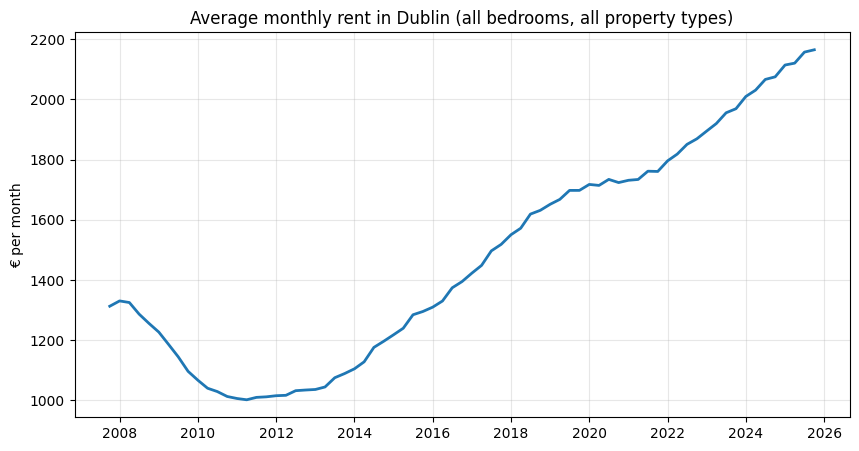

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(dublin["date"], dublin["value"], linewidth=2)
plt.title("Average monthly rent in Dublin (all bedrooms, all property types)")
plt.ylabel("€ per month")
plt.grid(alpha=0.3)
plt.savefig("rent_trend.png", bbox_inches="tight")
plt.show()

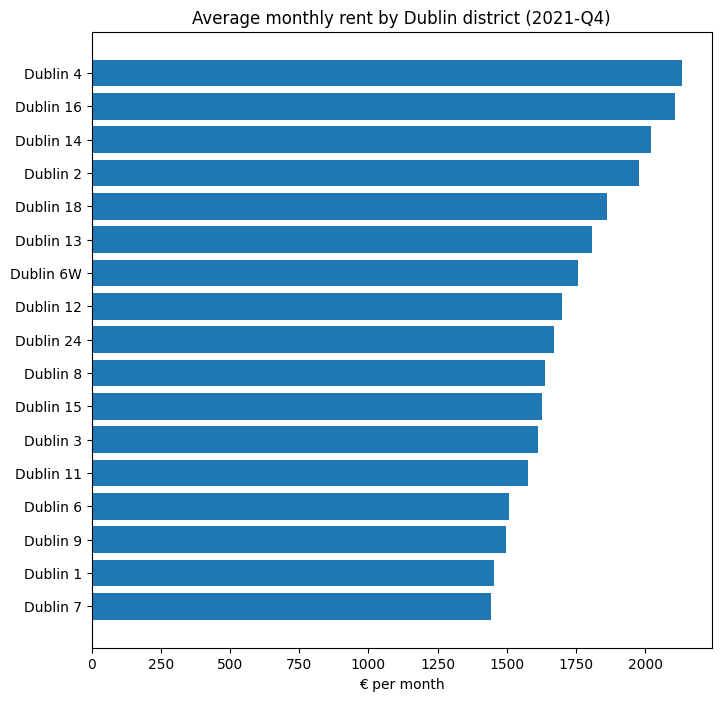

Most expensive:
        location    value
9035   Dublin 14  2020.77
10422  Dublin 16  2107.24
3925    Dublin 4  2132.77
Cheapest:
      location    value
5677  Dublin 7  1443.58
2100  Dublin 1  1452.85
7064  Dublin 9  1497.96


In [7]:
last_q = districts["period"].max()
rank = (districts[(districts["period"] == last_q) &
                  (districts["bedrooms"] == "All bedrooms") &
                  (districts["property_type"] == "All property types")]
        .sort_values("value"))

plt.figure(figsize=(8, 8))
plt.barh(rank["location"], rank["value"])
plt.title(f"Average monthly rent by Dublin district ({last_q})")
plt.xlabel("€ per month")
plt.savefig("rent_by_district.png", bbox_inches="tight")
plt.show()

print("Most expensive:")
print(rank[["location", "value"]].tail(3))
print("Cheapest:")
print(rank[["location", "value"]].head(3))

In [8]:
print(districts.groupby("location")["period"].max().sort_values())
print()
print(districts.groupby("period")["location"].nunique().tail(8))

location
Dublin 10    2021-Q3
Dublin 5     2021-Q3
Dublin 17    2021-Q3
Dublin 20    2021-Q3
Dublin 1     2021-Q4
Dublin 7     2021-Q4
Dublin 6W    2021-Q4
Dublin 6     2021-Q4
Dublin 4     2021-Q4
Dublin 3     2021-Q4
Dublin 24    2021-Q4
Dublin 2     2021-Q4
Dublin 18    2021-Q4
Dublin 16    2021-Q4
Dublin 15    2021-Q4
Dublin 14    2021-Q4
Dublin 13    2021-Q4
Dublin 12    2021-Q4
Dublin 11    2021-Q4
Dublin 8     2021-Q4
Dublin 9     2021-Q4
Name: period, dtype: object

period
2020-Q1    21
2020-Q2    21
2020-Q3    21
2020-Q4    21
2021-Q1    21
2021-Q2    21
2021-Q3    21
2021-Q4    17
Name: location, dtype: int64


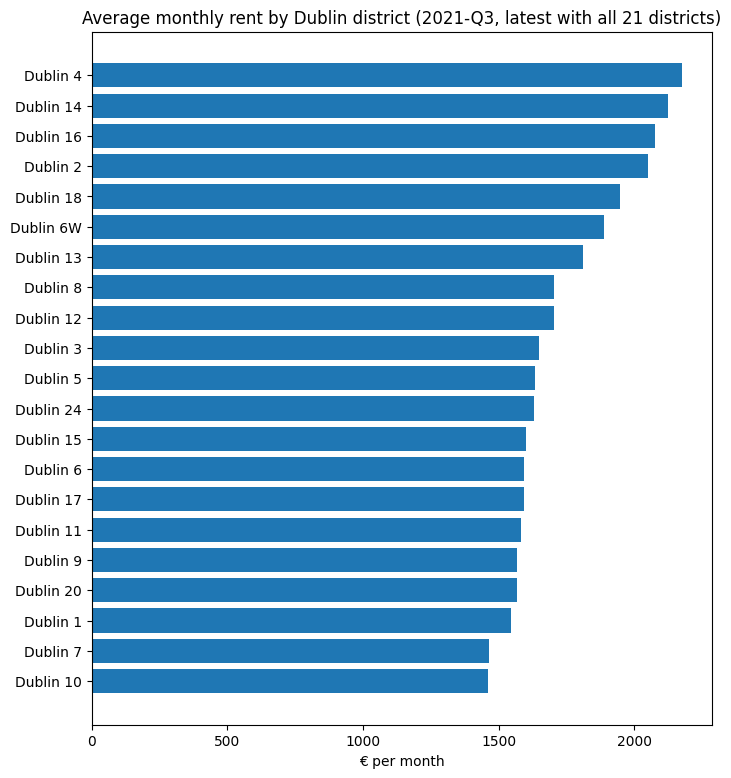

21 districts
Most expensive:
        location    value
10421  Dublin 16  2076.52
9034   Dublin 14  2123.56
3924    Dublin 4  2175.93
Cheapest:
       location    value
7574  Dublin 10  1461.80
5676   Dublin 7  1463.81
2099   Dublin 1  1544.47


In [9]:
q = "2021-Q3"
rank = (districts[(districts["period"] == q) &
                  (districts["bedrooms"] == "All bedrooms") &
                  (districts["property_type"] == "All property types")]
        .sort_values("value"))

plt.figure(figsize=(8, 9))
plt.barh(rank["location"], rank["value"])
plt.title(f"Average monthly rent by Dublin district ({q}, latest with all 21 districts)")
plt.xlabel("€ per month")
plt.savefig("rent_by_district.png", bbox_inches="tight")
plt.show()

print(len(rank), "districts")
print("Most expensive:")
print(rank[["location", "value"]].tail(3))
print("Cheapest:")
print(rank[["location", "value"]].head(3))

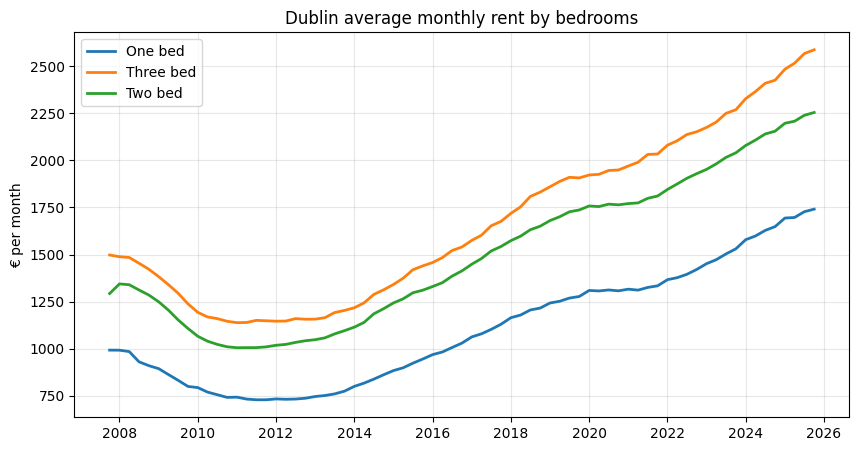

2025-Q4
         bedrooms    value
146364    Two bed  2253.28
73218     One bed  1740.68
219510  Three bed  2585.87


In [10]:
beds = df[(df["location"] == "Dublin") &
          (df["property_type"] == "All property types") &
          (df["bedrooms"].isin(["One bed", "Two bed", "Three bed"]))].sort_values("date")

plt.figure(figsize=(10, 5))
for b, g in beds.groupby("bedrooms"):
    plt.plot(g["date"].values, g["value"].values, label=b, linewidth=2)
plt.title("Dublin average monthly rent by bedrooms")
plt.ylabel("€ per month")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("rent_by_bedrooms.png", bbox_inches="tight")
plt.show()

latest_q = beds["period"].max()
print(latest_q)
print(beds[beds["period"] == latest_q][["bedrooms", "value"]])

In [11]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

s = dublin.set_index("date")["value"].asfreq("QS").interpolate()

train, test = s[:-8], s[-8:]
m = ExponentialSmoothing(train, trend="add", damped_trend=True).fit()
pred = m.forecast(8)

mape = np.mean(np.abs((test.values - pred.values) / test.values)) * 100
print("Backtest error (MAPE):", round(mape, 1), "%")
print()
print(pd.DataFrame({"actual": test.round(0), "predicted": pred.round(0)}))

Backtest error (MAPE): 1.5 %

            actual  predicted
2024-01-01  2010.0     1994.0
2024-04-01  2031.0     2015.0
2024-07-01  2066.0     2034.0
2024-10-01  2075.0     2053.0
2025-01-01  2114.0     2071.0
2025-04-01  2121.0     2089.0
2025-07-01  2157.0     2105.0
2025-10-01  2165.0     2121.0


2026-01-01    2186.0
2026-04-01    2203.0
2026-07-01    2219.0
2026-10-01    2234.0
Freq: QS-JAN, dtype: float64


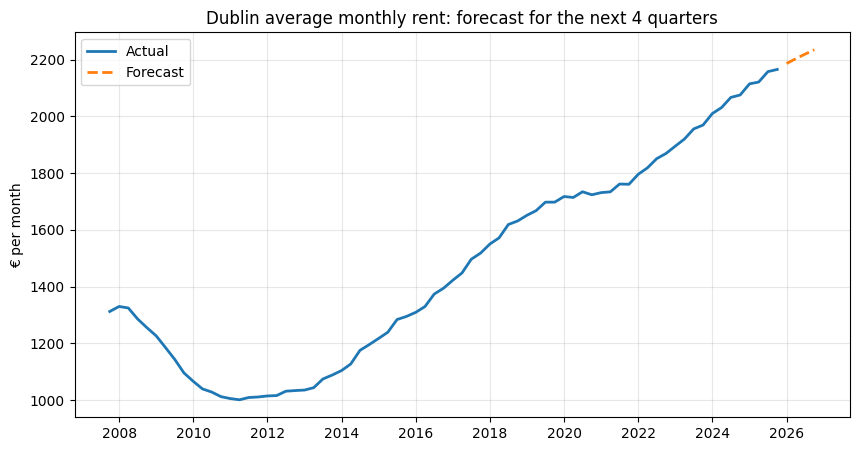

In [12]:
final = ExponentialSmoothing(s, trend="add", damped_trend=True).fit()
fc = final.forecast(4)
print(fc.round(0))

plt.figure(figsize=(10, 5))
plt.plot(s.index, s.values, label="Actual", linewidth=2)
plt.plot(fc.index, fc.values, "--", label="Forecast", linewidth=2)
plt.title("Dublin average monthly rent: forecast for the next 4 quarters")
plt.ylabel("€ per month")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("rent_forecast.png", bbox_inches="tight")
plt.show()

        bedrooms  monthly_rent  salary_needed
         One bed        1741.0        69600.0
All Dublin (avg)        2165.0        86600.0
         Two bed        2253.0        90100.0
       Three bed        2586.0       103400.0


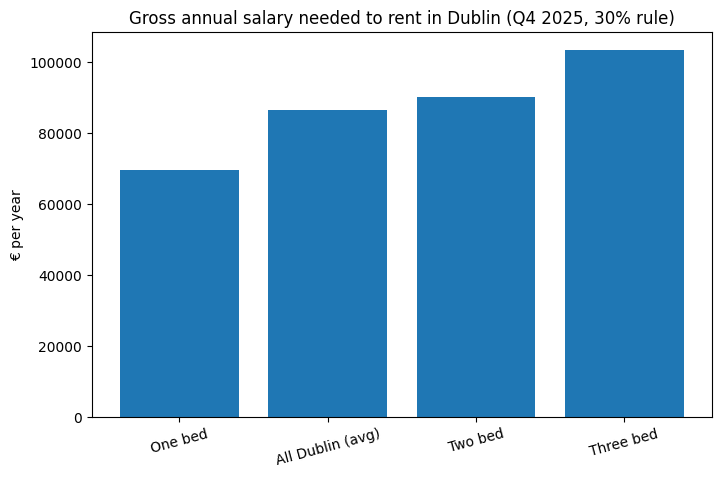

In [13]:
share = 0.30   # assumption: rent = 30% of gross income

latest = beds[beds["period"] == "2025-Q4"][["bedrooms", "value"]].copy()
latest = pd.concat([latest, pd.DataFrame([{"bedrooms": "All Dublin (avg)",
                                           "value": dublin.iloc[-1]["value"]}])])

latest["monthly_rent"] = latest["value"].round(0)
latest["salary_needed"] = (latest["value"] * 12 / share).round(-2)
latest = latest.drop(columns="value").sort_values("monthly_rent")
print(latest.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(latest["bedrooms"], latest["salary_needed"])
plt.title("Gross annual salary needed to rent in Dublin (Q4 2025, 30% rule)")
plt.ylabel("€ per year")
plt.xticks(rotation=15)
plt.savefig("salary_needed.png", bbox_inches="tight")
plt.show()

In [14]:
q = "2021-Q3"
dub_then = dublin[dublin["period"] == q]["value"].iloc[0]
dub_now = dublin.iloc[-1]["value"]

est = rank[["location", "value"]].copy()
est["vs_dublin_avg"] = (est["value"] / dub_then).round(2)
est["est_rent_now"] = (est["vs_dublin_avg"] * dub_now).round(0)
est["est_salary_needed"] = (est["est_rent_now"] * 12 / 0.30).round(-2)

print(est.tail(3).to_string(index=False))
print(est.head(3).to_string(index=False))

 location   value  vs_dublin_avg  est_rent_now  est_salary_needed
Dublin 16 2076.52           1.18        2555.0           102200.0
Dublin 14 2123.56           1.21        2620.0           104800.0
 Dublin 4 2175.93           1.24        2685.0           107400.0
 location   value  vs_dublin_avg  est_rent_now  est_salary_needed
Dublin 10 1461.80           0.83        1797.0            71900.0
 Dublin 7 1463.81           0.83        1797.0            71900.0
 Dublin 1 1544.47           0.88        1905.0            76200.0
